# Coin Detection System - Computer Vision Project
---

## Overview
This notebook detects and classifies coins in images using traditional computer vision techniques:
- **Circular Hough Transform** for circle detection
- **Size and Color analysis** for classification
- **No currency assumptions** - works for any coins worldwide

## Algorithm Pipeline
1. Load and preprocess image (grayscale + blur)
2. Detect circular shapes using Hough Transform
3. Extract features (radius, color) for each coin
4. Classify by size category and color
5. Group similar coins together
6. Visualize and summarize results

## Team Members
| Name                | ID      |
|---------------------|---------|
| Ahmed Hazem         | 22P0226 |
| Karim Hatem         | 22P0153 |
| Youssef Mostafa     | 22P0047 |
| Mostafa Foaad       | 22P0077 |
| AbdElRahman Mostafa | 22P0053 |

## Section 0 : Importing Libraries

In [1]:
import cv2
import os
import numpy as np
import math
from collections import Counter
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")
print(f"OpenCV version: {cv2.__version__}")

Libraries loaded successfully!
OpenCV version: 4.13.0


## Section 1 : Color Classification Functions
Defines coin colors (Silver, Gold, Copper, etc.)

Classify color based on HSV values

Parameters: hsv_color : tuple (Hue, Saturation, Value) values

Returns: (str) Color category name

In [2]:
# Section 1
def get_color_name(hsv_color):
    h, s, v = hsv_color

    # Very dark/black coins (some tokens, old coins)
    if v < 40:
        return "Dark/Black"

    # Silver/White coins (most modern coins: US quarters, dimes, Euro cents)
    if v > 180 and s < 40:
        return "Silver"

    # Gold/Brass coins (US dollars, some Euro coins, Arabic coins)
    if 15 <= h <= 35 and s > 40 and v > 100:
        return "Gold/Brass"

    # Copper/Bronze coins (US pennies, UK pennies, some Euro cents)
    if (h <= 15 or h >= 160) and s > 50 and v > 70:
        return "Copper/Bronze"

    # Nickel/Silver-gray tones (US nickels, some Euro coins)
    if 20 <= h <= 80 and s < 50 and v > 100:
        return "Nickel/Silver"

    # Yellowish coins (some commemorative coins, older gold-colored)
    if 25 <= h <= 45 and s > 40 and v > 120:
        return "Yellow/Gold"

    # Reddish-brown coins (very old copper coins, some tokens)
    if h <= 10 and s > 60 and 50 < v < 120:
        return "Reddish-Brown"

    # Gray coins (worn silver coins, some base metals)
    if s < 30 and 80 < v < 180:
        return "Gray"

    # Default for unusual coins
    return "Colored"

# Test the color function
test_colors = [
    (30, 100, 200),  # Should be Gold/Brass
    (10, 80, 150),   # Should be Copper/Bronze
    (60, 20, 220),   # Should be Silver
]

for hsv in test_colors:
    print(f"HSV {hsv} -> {get_color_name(hsv)}")

HSV (30, 100, 200) -> Gold/Brass
HSV (10, 80, 150) -> Copper/Bronze
HSV (60, 20, 220) -> Silver


## Section 2 : Size Classification

Size categories based on radius in pixels (adjustable for your image scale):

Classify coin size based on radius in pixels

Parameters: radius_pixels : (int) Radius of coin in pixels

Returns: (str) : Size category name

| Category | Radius Range |
|----------|--------------|
| Very Small | < 18 px |
| Small | 18-27 px |
| Medium | 28-37 px |
| Large | 38-49 px |
| Very Large | ≥ 50 px |

In [3]:
# Section 2 - Mathematical Dynamic Sizing
def get_dynamic_thresholds(coins_data):
    """Calculates boundaries based on the distribution of sizes in the current image."""
    if not coins_data:
        return None

    # We use radius for thresholds
    radii = [c['radius'] for c in coins_data]
    r_min, r_max = min(radii), max(radii)

    # Divide the spread into 3 equal mathematical intervals
    step = (r_max - r_min) / 3
    return {
        "small_limit": r_min + step,
        "medium_limit": r_min + 2 * step
    }

def get_size_category(radius, thresholds):
    """Assigns category based on the image's dynamic math."""
    if not thresholds:
        return "Unknown"
    if radius < thresholds["small_limit"]:
        return "Small"
    elif radius < thresholds["medium_limit"]:
        return "Medium"
    else:
        return "Large"

## Section 3 : Coin Detection (Hough Circle Transform)

Detects circular shapes in the image using Hough Circle Transform.

Parameters: image_path : str (path to image file)

Returns: (original_image, circles) or (None, None) if detection fails

Hough Parameters:
- dp=1 : Resolution ratio
- minDist=50 : Minimum distance between circle centers
- param1=100 : Edge detection threshold
- param2=30 : Circle detection sensitivity (lower = more circles)
- minRadius=10 : Minimum coin radius
- maxRadius=100 : Maximum coin radius

In [4]:
# Section 3 - High-Sensitivity Detection
def detect_coins(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, None

    # 1. Preprocessing
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Median Blur - Keep it high to ignore coin surface detail
    blurred = cv2.medianBlur(gray, 11)

    # 3. Adaptive Threshold - Increased block size (11 -> 25)
    # This helps pick up the full shape of the coin even in shadows
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 25, 3)

    # 4. Light Morphology
    # Using a smaller kernel (2,2) to prevent "shrinking" the coins too much
    kernel = np.ones((2,2), np.uint8)
    morphed = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

    # 5. Find Contours
    contours, _ = cv2.findContours(morphed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    valid_circles = []
    img_area = img.shape[0] * img.shape[1]

    for cnt in contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)

        if perimeter == 0: continue

        # Circularity Math
        circularity = 4 * np.pi * (area / (perimeter * perimeter))

        # --- ADJUSTED THRESHOLDS ---
        # 1. Lowered area requirement to 0.01% to catch small coins
        # 2. Widened circularity to 0.45 - 1.5 to catch distorted/packed coins
        if area > (img_area * 0.0001) and 0.45 < circularity < 1.5:
            (x, y), radius = cv2.minEnclosingCircle(cnt)

            # Additional check: prevent tiny "speck" detections
            if radius > 10:
                valid_circles.append([int(x), int(y), int(radius)])

    if not valid_circles:
        return img, None

    print(f"Detected {len(valid_circles)} coins in {os.path.basename(image_path)}")
    return img, np.array(valid_circles)

## Section 4 : Feature Extraction

Extracts size and color features from each detected coin.

Parameters:
- original_image : numpy.ndarray (BGR image)
- circles : numpy.ndarray (detected circles)

Returns: list of dictionaries containing coin features (id, center, radius, diameter, color, size, etc.)

In [5]:
# Section 4 - Enhanced Feature Extraction
import math

def extract_coin_features(original_image, circles, thresholds):
    coin_features = []

    for i, (x, y, r) in enumerate(circles):
        # 1. Create a precise mask for the coin
        mask = np.zeros(original_image.shape[:2], dtype=np.uint8)
        cv2.circle(mask, (int(x), int(y)), int(r), 255, -1)

        # 2. Calculate color in HSV space
        mean_bgr = cv2.mean(original_image, mask=mask)[:3]
        mean_bgr_uint8 = np.uint8([[mean_bgr]])
        mean_hsv = cv2.cvtColor(mean_bgr_uint8, cv2.COLOR_BGR2HSV)[0][0]

        # 3. Build the feature dictionary with all expected keys
        coin_features.append({
            'id': i + 1,
            'center': (int(x), int(y)),
            'radius': int(r),
            'diameter_pixels': int(r * 2), # Required for print_summary
            'area_pixels': math.pi * (r ** 2),
            'color': get_color_name(mean_hsv),
            'size': get_size_category(r, thresholds), # Dynamic classification
            'bgr': mean_bgr,
            'hsv': mean_hsv
        })

    return coin_features

## Section 5 : Coin Grouping

Groups coins that share the same size category AND color.

Parameters: coins : list (coin features from Section 5)

Returns: list of groups with group ID, count, size, color, and average measurements

In [6]:
# Section 5 - Dynamic Grouping with Statistics
def group_similar_coins(coins):
    groups_dict = {}

    for coin in coins:
        # Group by the unique combination of Color and Dynamic Size
        group_key = f"{coin['color']}_{coin['size']}"

        if group_key not in groups_dict:
            groups_dict[group_key] = {
                'id': len(groups_dict) + 1,
                'count': 0,
                'coins': [],
                'color': coin['color'],
                'size': coin['size']
            }

        groups_dict[group_key]['count'] += 1
        groups_dict[group_key]['coins'].append(coin)

    # Calculate statistical averages for each group
    final_groups = []
    for key in groups_dict:
        group = groups_dict[key]
        group['avg_radius'] = np.mean([c['radius'] for c in group['coins']])
        group['avg_diameter'] = np.mean([c['diameter_pixels'] for c in group['coins']])
        final_groups.append(group)

    # Sort groups by coin count (most frequent first)
    final_groups.sort(key=lambda x: x['count'], reverse=True)
    return final_groups

## Section 6 : Image Annotation

Draws results on the image. Circle colors are chosen from realistic metallic/coin colors (no pink, magenta, cyan, etc.)

Parameters:
- image : numpy.ndarray (image to annotate)
- coins : list (coin features)
- groups : list (coin groups)

Returns: annotated image

In [7]:
# Section 6
def annotate_image(image, coins, groups):
    # Realistic colors that might appear on coins or currency
    group_colors = [
        (192, 192, 192),  # Silver
        (218, 165, 32),   # Goldenrod
        (205, 127, 50),   # Copper
        (169, 169, 169),  # Dark Gray
        (255, 215, 0),    # Gold
        (210, 105, 30),   # Bronze
        (128, 128, 128),  # Gray
        (238, 232, 170),  # Pale Goldenrod
        (184, 115, 51),   # Peru (brownish-gold)
        (192, 192, 192),  # Light Silver
    ]

    group_color_map = {}
    for i, group in enumerate(groups):
        group_color_map[group['id']] = group_colors[i % len(group_colors)]

    for coin in coins:
        x, y = coin['center']
        r = coin['radius']

        group_id = None
        for group in groups:
            if coin in group['coins']:
                group_id = group['id']
                break

        if group_id:
            color = group_color_map[group_id]

            cv2.circle(image, (x, y), r, color, 4)
            cv2.circle(image, (x, y), 3, color, -1)

            label = f"G{group_id}: {coin['color']}, {coin['size']}"
            text_x, text_y = x - r, y - r - 10

            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(image, (text_x - 5, text_y - text_h - 5),
                         (text_x + text_w + 5, text_y + 5), (0, 0, 0), -1)
            cv2.rectangle(image, (text_x - 5, text_y - text_h - 5),
                         (text_x + text_w + 5, text_y + 5), color, 2)
            cv2.putText(image, label, (text_x, text_y),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    return image

## Section 7 : Results Summary

Prints formatted summary to console and creates statistics image.

Parameters: coins, groups (from previous sections)

Returns: None (prints to console and saves image)

In [8]:
# Section 7
def print_summary(coins, groups):
    print("\n" + "="*60)
    print("COIN DETECTION & CLASSIFICATION SUMMARY")
    print("="*60)
    print(f"\n📊 TOTAL: {len(coins)} coins detected\n")

    print("📋 CLASSIFICATION BY GROUPS:")
    print("-"*60)
    for group in groups:
        print(f"\n GROUP {group['id']}: {group['count']} coins")
        print(f"      Size: {group['size']}")
        print(f"      Color: {group['color']}")
        print(f"      Avg Diameter: {group['avg_diameter']:.1f} pixels")
        print(f"      Coin IDs: {[c['id'] for c in group['coins']]}")

    print("\n" + "-"*60)
    color_counts = Counter([c['color'] for c in coins])
    print("\n🎨 By Color:")
    for color, count in color_counts.most_common():
        print(f"   {color:15s}: {count:2d} coins ({count/len(coins)*100:.1f}%)")

    size_counts = Counter([c['size'] for c in coins])
    print("\n📏 By Size:")
    for size, count in size_counts.most_common():
        print(f"   {size:12s}: {count:2d} coins ({count/len(coins)*100:.1f}%)")

    print("\n" + "="*60)

def create_stats_image(coins, groups):
    stats_img = np.zeros((600, 500, 3), dtype=np.uint8)
    y = 50

    cv2.putText(stats_img, "CLASSIFICATION STATISTICS", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    y += 70

    cv2.putText(stats_img, f"Total Coins: {len(coins)}", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (100, 255, 100), 2)
    y += 40

    cv2.putText(stats_img, "Groups Found:", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 200, 100), 2)
    y += 30

    for group in groups[:8]:
        text = f"Group {group['id']}: {group['count']} coins - {group['color']}, {group['size']}"
        cv2.putText(stats_img, text, (70, y),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        y += 25

    return stats_img

## Section 8

--- Processing: Coins_1.jpg ---
Detected 27 coins in Coins_1.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 27 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 3: 9 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 217.8 pixels
      Coin IDs: [3, 7, 11, 14, 15, 16, 17, 22, 23]

 GROUP 1: 4 coins
      Size: Medium
      Color: Copper/Bronze
      Avg Diameter: 160.0 pixels
      Coin IDs: [1, 9, 12, 21]

 GROUP 5: 4 coins
      Size: Large
      Color: Silver
      Avg Diameter: 238.0 pixels
      Coin IDs: [6, 19, 25, 26]

 GROUP 2: 3 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 239.3 pixels
      Coin IDs: [2, 20, 24]

 GROUP 4: 2 coins
      Size: Large
      Color: Gray
      Avg Diameter: 211.0 pixels
      Coin IDs: [4, 5]

 GROUP 6: 1 coins
      Size: Medium
      Color: Nickel/Silver
      Avg Diameter: 160.0 pixels
      Coin IDs: [8]

 GROUP 7: 1 coins
      S

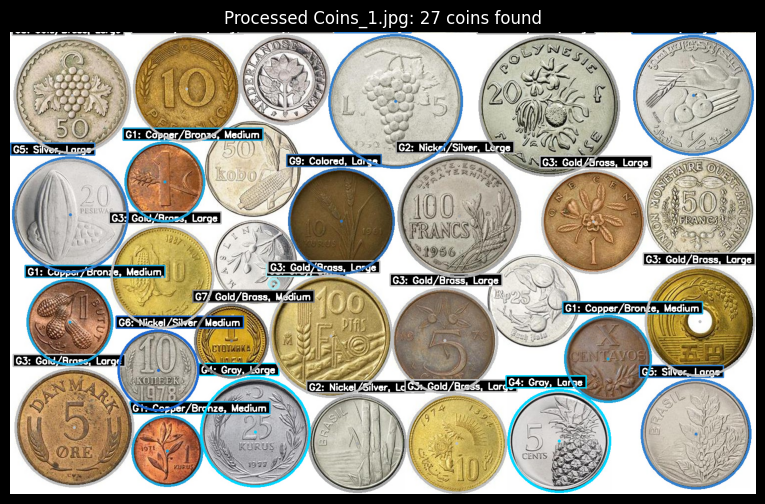

--- Processing: Coins_2.jpg ---
Detected 53 coins in Coins_2.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 53 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 3: 16 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 218.4 pixels
      Coin IDs: [3, 4, 5, 11, 18, 19, 24, 25, 28, 33, 35, 42, 44, 45, 48, 52]

 GROUP 8: 9 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 265.1 pixels
      Coin IDs: [13, 15, 22, 23, 31, 37, 41, 46, 53]

 GROUP 10: 6 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 166.3 pixels
      Coin IDs: [16, 21, 26, 30, 34, 43]

 GROUP 5: 4 coins
      Size: Large
      Color: Silver
      Avg Diameter: 258.5 pixels
      Coin IDs: [7, 8, 32, 38]

 GROUP 9: 4 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 253.0 pixels
      Coin IDs: [14, 40, 49, 51]

 GROUP 4: 3 coins
      Size: Medium
      Color: Gray
      Avg Di

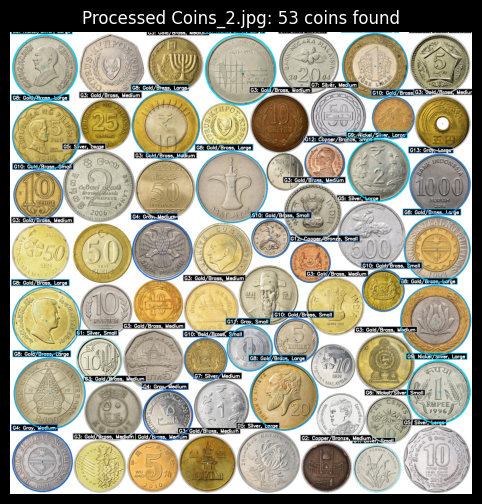

--- Processing: Coins_3.jpg ---
Detected 17 coins in Coins_3.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 17 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 6: 4 coins
      Size: Large
      Color: Silver
      Avg Diameter: 201.5 pixels
      Coin IDs: [8, 12, 15, 16]

 GROUP 1: 3 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 192.0 pixels
      Coin IDs: [1, 3, 6]

 GROUP 8: 2 coins
      Size: Large
      Color: Copper/Bronze
      Avg Diameter: 165.0 pixels
      Coin IDs: [10, 13]

 GROUP 2: 1 coins
      Size: Large
      Color: Gray
      Avg Diameter: 194.0 pixels
      Coin IDs: [2]

 GROUP 3: 1 coins
      Size: Medium
      Color: Colored
      Avg Diameter: 140.0 pixels
      Coin IDs: [4]

 GROUP 4: 1 coins
      Size: Small
      Color: Colored
      Avg Diameter: 24.0 pixels
      Coin IDs: [5]

 GROUP 5: 1 coins
      Size: Large
      Color: Colored
      Avg Diameter: 164.

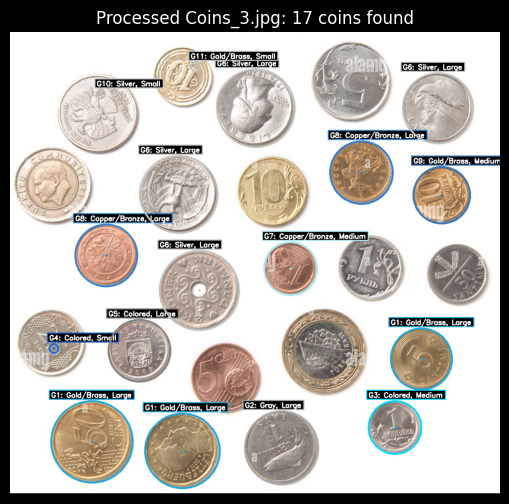

--- Processing: Coins_4.jpg ---
Detected 25 coins in Coins_4.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 25 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 2: 7 coins
      Size: Large
      Color: Gray
      Avg Diameter: 156.6 pixels
      Coin IDs: [3, 5, 9, 15, 16, 17, 23]

 GROUP 3: 7 coins
      Size: Large
      Color: Copper/Bronze
      Avg Diameter: 144.0 pixels
      Coin IDs: [4, 6, 8, 13, 14, 19, 25]

 GROUP 1: 4 coins
      Size: Medium
      Color: Copper/Bronze
      Avg Diameter: 123.5 pixels
      Coin IDs: [1, 2, 12, 21]

 GROUP 5: 3 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 124.0 pixels
      Coin IDs: [10, 11, 20]

 GROUP 4: 1 coins
      Size: Medium
      Color: Gray
      Avg Diameter: 128.0 pixels
      Coin IDs: [7]

 GROUP 6: 1 coins
      Size: Large
      Color: Colored
      Avg Diameter: 150.0 pixels
      Coin IDs: [18]

 GROUP 7: 1 coins
      Size: Sm

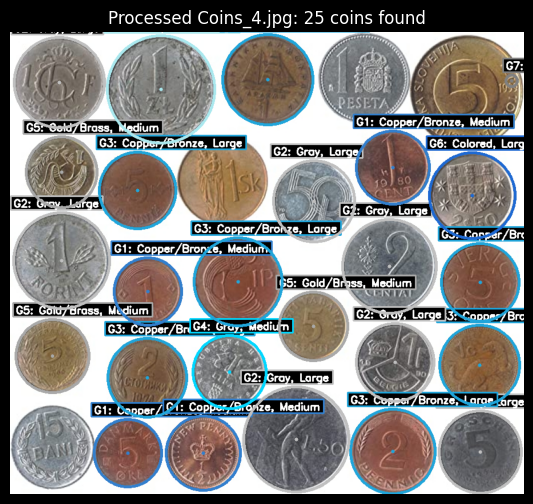

--- Processing: Coins_5.jpg ---
Detected 9 coins in Coins_5.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 9 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 4: 3 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 49.3 pixels
      Coin IDs: [6, 8, 9]

 GROUP 1: 2 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 61.0 pixels
      Coin IDs: [1, 2]

 GROUP 3: 2 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 72.0 pixels
      Coin IDs: [4, 5]

 GROUP 2: 1 coins
      Size: Medium
      Color: Nickel/Silver
      Avg Diameter: 62.0 pixels
      Coin IDs: [3]

 GROUP 5: 1 coins
      Size: Small
      Color: Nickel/Silver
      Avg Diameter: 50.0 pixels
      Coin IDs: [7]

------------------------------------------------------------

🎨 By Color:
   Gold/Brass     :  5 coins (55.6%)
   Nickel/Silver  :  4 coins (44.4%)

📏 By Size:
   Small       :  4 coins (44

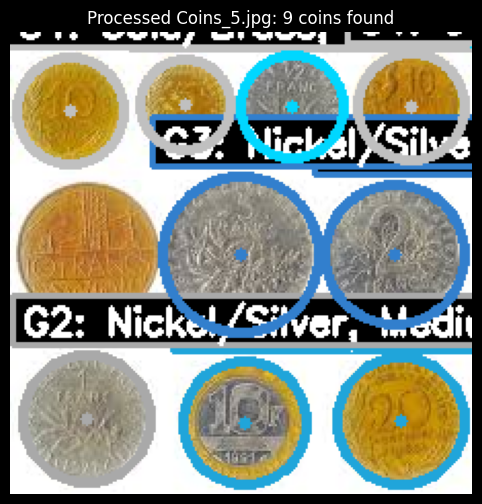

--- Processing: Coins_6.jpg ---
Detected 4 coins in Coins_6.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 4 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 3: 2 coins
      Size: Medium
      Color: Silver
      Avg Diameter: 58.0 pixels
      Coin IDs: [3, 4]

 GROUP 1: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 54.0 pixels
      Coin IDs: [1]

 GROUP 2: 1 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 64.0 pixels
      Coin IDs: [2]

------------------------------------------------------------

🎨 By Color:
   Gold/Brass     :  2 coins (50.0%)
   Silver         :  2 coins (50.0%)

📏 By Size:
   Medium      :  2 coins (50.0%)
   Small       :  1 coins (25.0%)
   Large       :  1 coins (25.0%)



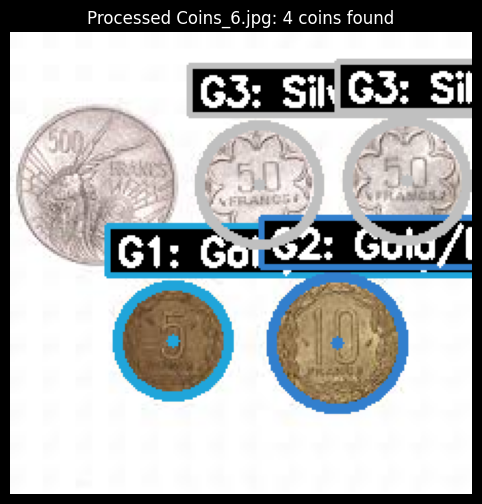

In [9]:
# Section 8 - Automated Folder Processing & Extraction
input_folder = "data"
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

valid_exts = (".jpg", ".jpeg", ".png")
images = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_exts)]

for filename in images:
    path = os.path.join(input_folder, filename)
    print(f"--- Processing: {filename} ---")

    # 1. Detect
    img, circles = detect_coins(path)

    if circles is not None:
        img_name = os.path.splitext(filename)[0]
        img_dir = os.path.join(output_folder, img_name)
        os.makedirs(img_dir, exist_ok=True)

        # 2. Calculate dynamic thresholds for this image
        coin_list = [{'radius': c[2]} for c in circles]
        thresholds = get_dynamic_thresholds(coin_list)

        # 3. Extract Features (Now includes diameter_pixels)
        features = extract_coin_features(img, circles, thresholds)

        # 4. Group (Now includes avg_diameter)
        groups = group_similar_coins(features)

        # 5. Print Summary (Will now find 'avg_diameter')
        print_summary(features, groups)
        stats_img = create_stats_image(features, groups)

        # 6. Extraction Loop
        for i, coin in enumerate(features):
            x, y = coin['center']
            r = coin['radius']
            pad = int(r * 0.1)
            y1, y2 = max(0, y-r-pad), min(img.shape[0], y+r+pad)
            x1, x2 = max(0, x-r-pad), min(img.shape[1], x+r+pad)
            coin_crop = img[y1:y2, x1:x2]

            if coin_crop.size > 0:
                cv2.imwrite(os.path.join(img_dir, f"coin_{i+1}_{coin['color']}_{coin['size']}.png"), coin_crop)

        # 7. Final Output
        processed_img = annotate_image(img.copy(), features, groups)
        cv2.imwrite(os.path.join(img_dir, "_summary_annotated.jpg"), processed_img)

        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Processed {filename}: {len(features)} coins found")
        plt.axis('off')
        plt.show()
    else:
        print(f"Skipping {filename}: No coins found.")